# LogReg With Amount

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, confusion_matrix, PrecisionRecallDisplay
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [3]:
DROPPED = ['Class', 'Time', 'V23', 'V27', 'V28', 'V26', 'V25', 'V22', 'V15', 'V13', 'V24']
TOP_N    = 12        
MIN_FEATURES = 3     

In [4]:
df = pd.read_csv('creditcard.csv')
ALL_FEATURES = [c for c in df.columns if c not in DROPPED]
print(f"Available features ({len(ALL_FEATURES)}): {ALL_FEATURES}\n")

X_all = df[ALL_FEATURES]
y     = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)

def evaluate(features):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_test[list(features)])
    y_probs = model.predict_proba(X_test[list(features)])[:, 1]
    return {
        'recall':    recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'pr_auc':    average_precision_score(y_test, y_probs),
    }

results = []

Available features (19): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21']



## FORWARD STEPWISE RECALL

In [5]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["recall"]
        else:
            m = evaluate(candidate)
            score = m["recall"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…



/Users/hyunjoonchoi/Documents/CodeProjects/CardGuard/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hyunjoonchoi/Documents/CodeProjects/CardGuard/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hyunjoonchoi/Documents/CodeProjects/CardGuard/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this beha

  Added 'V14' → recall=0.4898  precision=0.6486  f1=0.5581  [1 features]
  Added 'V12' → recall=0.5816  precision=0.8143  f1=0.6786  [2 features]
  Added 'V4' → recall=0.5918  precision=0.7733  f1=0.6705  [3 features]
  Added 'V16' → recall=0.6020  precision=0.8194  f1=0.6941  [4 features]
  Added 'V1' → recall=0.6122  precision=0.8333  f1=0.7059  [5 features]
  Added 'V2' → recall=0.6122  precision=0.8333  f1=0.7059  [6 features]
  Added 'V10' → recall=0.6327  precision=0.8158  f1=0.7126  [7 features]
  Added 'V11' → recall=0.6327  precision=0.8158  f1=0.7126  [8 features]
  Added 'V5' → recall=0.6224  precision=0.8133  f1=0.7052  [9 features]
  Added 'V20' → recall=0.6327  precision=0.8158  f1=0.7126  [10 features]
  Added 'V8' → recall=0.6429  precision=0.8289  f1=0.7241  [11 features]
  Added 'V9' → recall=0.6429  precision=0.8289  f1=0.7241  [12 features]
  Added 'V21' → recall=0.6531  precision=0.8312  f1=0.7314  [13 features]
  Added 'V3' → recall=0.6531  precision=0.8312  f1=0.

In [6]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_unbalanced_recall_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (17 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7407
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21', 'V3', 'V19', 'V6', 'V18']

Rank 2  (13 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7397
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21']

Rank 3  (14 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7379
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21', 'V3']

Rank 4  (16 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7419
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21', 'V3', 'V19', 'V6']


## FORWARD STEPWISE PR AUC

In [7]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["pr_auc"]
        else:
            m = evaluate(candidate)
            score = m["pr_auc"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…



/Users/hyunjoonchoi/Documents/CodeProjects/CardGuard/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hyunjoonchoi/Documents/CodeProjects/CardGuard/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hyunjoonchoi/Documents/CodeProjects/CardGuard/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this beha

  Added 'V17' → recall=0.4184  precision=0.7593  f1=0.5395  [1 features]
  Added 'V14' → recall=0.5816  precision=0.8143  f1=0.6786  [2 features]
  Added 'V10' → recall=0.5816  precision=0.8143  f1=0.6786  [3 features]
  Added 'V8' → recall=0.5816  precision=0.8261  f1=0.6826  [4 features]
  Added 'V16' → recall=0.5918  precision=0.8286  f1=0.6905  [5 features]
  Added 'V6' → recall=0.6020  precision=0.8310  f1=0.6982  [6 features]
  Added 'V21' → recall=0.6122  precision=0.8333  f1=0.7059  [7 features]
  Added 'V2' → recall=0.6122  precision=0.8333  f1=0.7059  [8 features]
  Added 'V20' → recall=0.6122  precision=0.8333  f1=0.7059  [9 features]
  Added 'V18' → recall=0.6122  precision=0.8333  f1=0.7059  [10 features]
  Added 'V12' → recall=0.6122  precision=0.8333  f1=0.7059  [11 features]
  Added 'V11' → recall=0.6122  precision=0.8333  f1=0.7059  [12 features]
  Added 'V19' → recall=0.6122  precision=0.8333  f1=0.7059  [13 features]
  Added 'V4' → recall=0.6429  precision=0.8289  f1

In [8]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_unbalanced_pr_auc_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (16 features)
  Recall:    0.6327
  Precision: 0.8267
  F1:        0.7168
  PR AUC:    0.7442
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V6', 'V21', 'V2', 'V20', 'V18', 'V12', 'V11', 'V19', 'V4', 'V3', 'V1']

Rank 2  (10 features)
  Recall:    0.6122
  Precision: 0.8333
  F1:        0.7059
  PR AUC:    0.7426
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V6', 'V21', 'V2', 'V20', 'V18']

Rank 3  (17 features)
  Recall:    0.6429
  Precision: 0.8289
  F1:        0.7241
  PR AUC:    0.7425
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V6', 'V21', 'V2', 'V20', 'V18', 'V12', 'V11', 'V19', 'V4', 'V3', 'V1', 'V7']

Rank 4  (15 features)
  Recall:    0.6429
  Precision: 0.8289
  F1:        0.7241
  PR AUC:    0.7424
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21', 'V3', 'V18']

Rank 5 

## TOP N RECALL

In [10]:
print("Ranking features by logistic regression importance…")
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train, y_train)
importances = pd.Series(np.abs(base_model.coef_[0]), index=ALL_FEATURES)
top_features = importances.nlargest(TOP_N).index.tolist()
print(f"Top {TOP_N} features: {top_features}\n")

total = sum(1 for k in range(MIN_FEATURES, len(top_features)+1)
            for _ in combinations(top_features, k))
print(f"Exhaustive search over top {TOP_N}: {total:,} combinations…\n")
done = 0
for k in range(MIN_FEATURES, len(top_features) + 1):
    for combo in combinations(top_features, k):
        metrics = evaluate(combo)
        results.append({'features': list(combo), **metrics})
        done += 1
        if done % 200 == 0:
            print(f"  {done:,} / {total:,} done…")

Ranking features by logistic regression importance…
Top 12 features: ['V14', 'V4', 'V10', 'V16', 'V8', 'V21', 'V9', 'V5', 'V19', 'V20', 'V17', 'V6']

Exhaustive search over top 12: 4,017 combinations…

  200 / 4,017 done…
  400 / 4,017 done…
  600 / 4,017 done…
  800 / 4,017 done…
  1,000 / 4,017 done…
  1,200 / 4,017 done…
  1,400 / 4,017 done…
  1,600 / 4,017 done…
  1,800 / 4,017 done…
  2,000 / 4,017 done…
  2,200 / 4,017 done…
  2,400 / 4,017 done…
  2,600 / 4,017 done…
  2,800 / 4,017 done…
  3,000 / 4,017 done…
  3,200 / 4,017 done…
  3,400 / 4,017 done…
  3,600 / 4,017 done…
  3,800 / 4,017 done…
  4,000 / 4,017 done…


In [11]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_unbalanced_recall_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (14 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7377
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21', 'V18']

Rank 2  (14 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7406
  Features:  ['V14', 'V12', 'V4', 'V16', 'V1', 'V2', 'V10', 'V11', 'V5', 'V20', 'V8', 'V9', 'V21', 'V7']

Rank 3  (15 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7407
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V6', 'V21', 'V2', 'V20', 'V18', 'V12', 'V11', 'V19', 'V4', 'V1']

Rank 4  (15 features)
  Recall:    0.6531
  Precision: 0.8312
  F1:        0.7314
  PR AUC:    0.7421
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V6', 'V21', 'V2', 'V20', 'V18', 'V12', 'V11', 'V19', 'V4', 'V3']

Rank 5 

In [12]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_unbalanced_pr_auc_amount.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (16 features)
  Recall:    0.6327
  Precision: 0.8267
  F1:        0.7168
  PR AUC:    0.7442
  Features:  ['V17', 'V14', 'V10', 'V8', 'V16', 'V6', 'V21', 'V2', 'V20', 'V18', 'V12', 'V11', 'V19', 'V4', 'V3', 'V1']

Rank 2  (7 features)
  Recall:    0.6224
  Precision: 0.8243
  F1:        0.7093
  PR AUC:    0.7441
  Features:  ['V14', 'V4', 'V10', 'V16', 'V8', 'V21', 'V5']

Rank 3  (8 features)
  Recall:    0.6224
  Precision: 0.8243
  F1:        0.7093
  PR AUC:    0.7436
  Features:  ['V14', 'V4', 'V10', 'V16', 'V8', 'V21', 'V5', 'V19']

Rank 4  (9 features)
  Recall:    0.6327
  Precision: 0.8267
  F1:        0.7168
  PR AUC:    0.7433
  Features:  ['V14', 'V4', 'V10', 'V16', 'V8', 'V21', 'V5', 'V17', 'V6']

Rank 5  (8 features)
  Recall:    0.6224
  Precision: 0.8243
  F1:        0.7093
  PR AUC:    0.7432
  Features:  ['V14', 'V4', '

# Compare the results

In [13]:
forward_stepwise_recall = pd.read_csv('csv_new/logreg_fs_unbalanced_recall.csv')
top_n_recall = pd.read_csv('csv_new/logreg_top_n_unbalanced_recall.csv')

forward_stepwise_recall_amount = pd.read_csv('csv_new/logreg_fs_unbalanced_recall_amount.csv')
top_n_recall_amount = pd.read_csv('csv_new/logreg_top_n_unbalanced_recall_amount.csv')

print("\n══════════════════════════════════════════════════════")
print("BEST OF RECALL — SIDE BY SIDE")
print("══════════════════════════════════════════════════════")
metrics = ['recall', 'precision', 'f1', 'pr_auc']
summary = pd.DataFrame({
    'Metric': metrics,
    'Forward_Stepwise': [forward_stepwise_recall[m].iloc[0] for m in metrics],
    'Top_N': [top_n_recall[m].iloc[0] for m in metrics],
    'Forward_Stepwise_With_Amount': [forward_stepwise_recall_amount[m].iloc[0] for m in metrics],
    'Top_N_With_Amount': [top_n_recall_amount[m].iloc[0] for m in metrics],
})
cols = ['Forward_Stepwise', 'Top_N', 'Forward_Stepwise_With_Amount', 'Top_N_With_Amount']
summary['Best_Value'] = summary[cols].max(axis=1)
summary['Winner'] = summary[cols].idxmax(axis=1)

print(summary.to_string(index=False))


══════════════════════════════════════════════════════
BEST OF RECALL — SIDE BY SIDE
══════════════════════════════════════════════════════
   Metric  Forward_Stepwise    Top_N  Difference           Winner
   recall          0.653061 0.653061    0.000000              Tie
precision          0.831169 0.831169    0.000000              Tie
       f1          0.731429 0.731429    0.000000              Tie
   pr_auc          0.740670 0.737708   -0.002962 Forward_Stepwise


In [14]:
forward_stepwise_recall = pd.read_csv('csv_new/logreg_fs_unbalanced_pr_auc.csv')
top_n_recall = pd.read_csv('csv_new/logreg_top_n_unbalanced_pr_auc.csv')

forward_stepwise_pr_auc_amount = pd.read_csv('csv_new/logreg_fs_unbalanced_pr_auc_amount.csv')
top_n_pr_auc_amount = pd.read_csv('csv_new/logreg_top_n_unbalanced_pr_auc_amount.csv')

print("\n══════════════════════════════════════════════════════")
print("BEST OF PR AUC — SIDE BY SIDE")
print("══════════════════════════════════════════════════════")
metrics = ['recall', 'precision', 'f1', 'pr_auc']
summary = pd.DataFrame({
    'Metric': metrics,
    'Forward_Stepwise': [forward_stepwise_recall[m].iloc[0] for m in metrics],
    'Top_N': [top_n_recall[m].iloc[0] for m in metrics],
    'Forward_Stepwise_With_Amount': [forward_stepwise_recall[m].iloc[0] for m in metrics],
    'Top_N_With_Amount': [top_n_recall[m].iloc[0] for m in metrics],
})
cols = ['Forward_Stepwise', 'Top_N', 'Forward_Stepwise_With_Amount', 'Top_N_With_Amount']
summary['Best_Value'] = summary[cols].max(axis=1)
summary['Winner'] = summary[cols].idxmax(axis=1)

print(summary.to_string(index=False))


══════════════════════════════════════════════════════
BEST OF PR AUC — SIDE BY SIDE
══════════════════════════════════════════════════════
   Metric  Forward_Stepwise    Top_N  Difference Winner
   recall          0.632653 0.632653         0.0    Tie
precision          0.826667 0.826667         0.0    Tie
       f1          0.716763 0.716763         0.0    Tie
   pr_auc          0.744172 0.744172         0.0    Tie


# Generate HeatMap

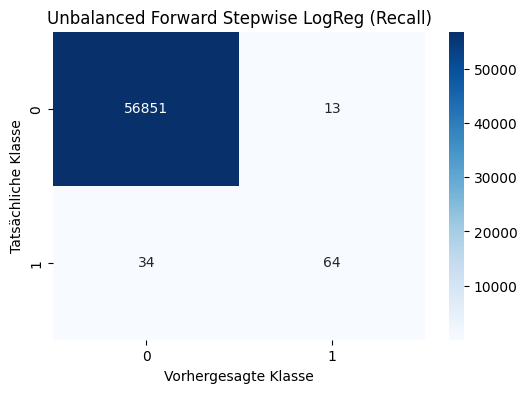

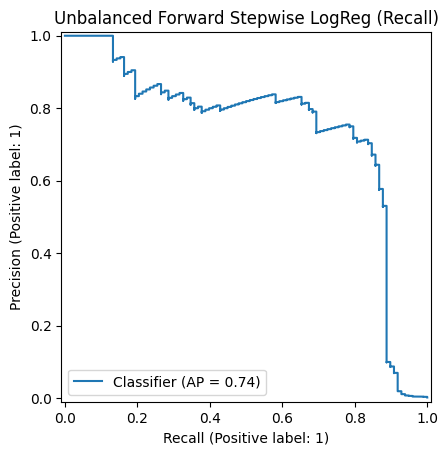

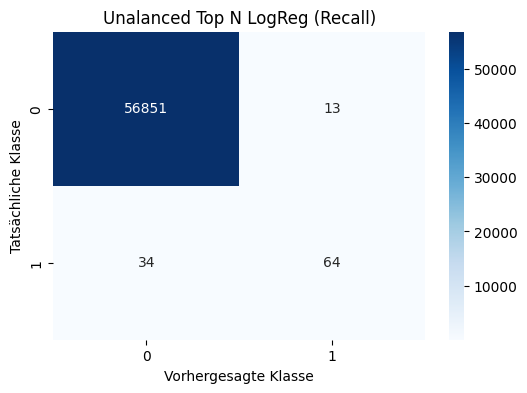

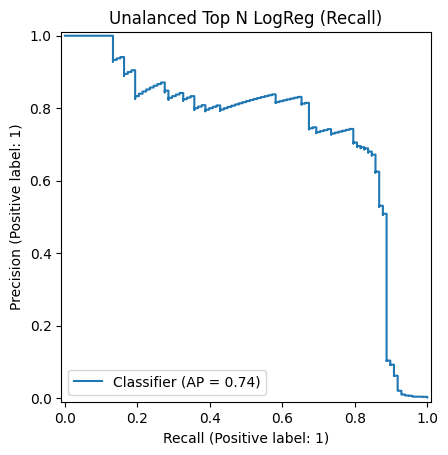

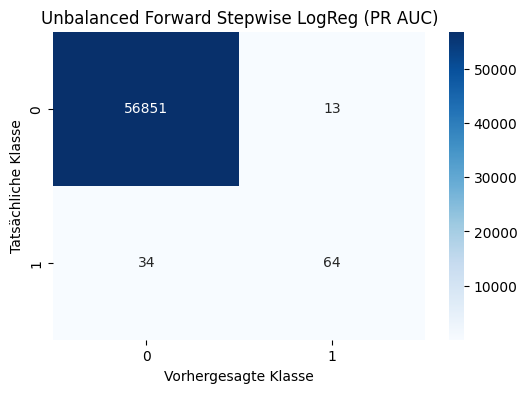

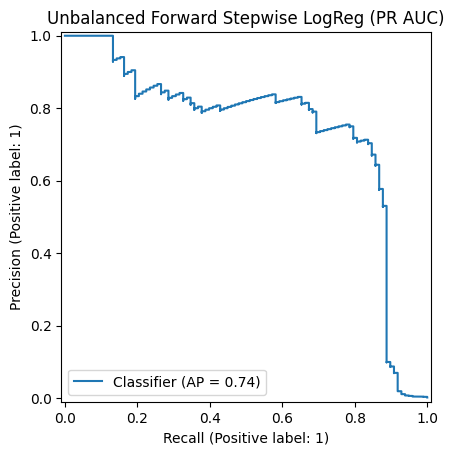

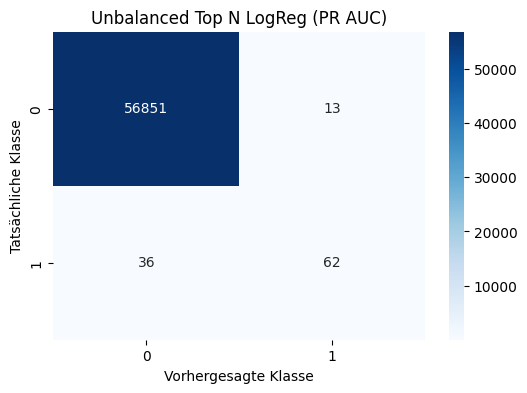

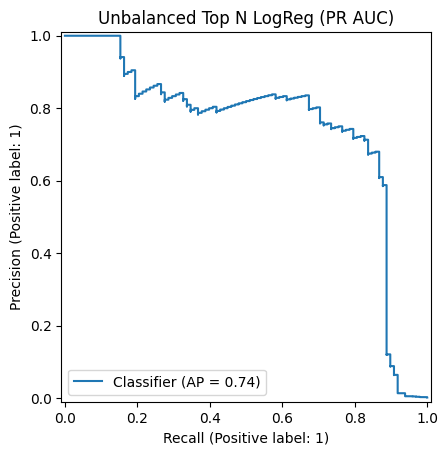

In [16]:
def evaluate(features, title):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_test[list(features)])
    y_probs = model.predict_proba(X_test[list(features)])[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Tatsächliche Klasse')
    plt.xlabel('Vorhergesagte Klasse')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_probs)
    plt.title(title)
    plt.show()


evaluate(ast.literal_eval(forward_stepwise_recall_amount['features'].iloc[0]), "Unbalanced Forward Stepwise LogReg (Recall + Amount)")
evaluate(ast.literal_eval(top_n_recall_amount['features'].iloc[0]), "Unalanced Top N LogReg (Recall + Amount)")

evaluate(ast.literal_eval(forward_stepwise_pr_auc_amount['features'].iloc[0]), "Unbalanced Forward Stepwise LogReg (PR AUC + Amount)")
evaluate(ast.literal_eval(top_n_pr_auc_amount['features'].iloc[0]), "Unbalanced Top N LogReg (PR AUC + Amount)")